In [1]:
!pip install wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.7/550.7 kB 1.5 MB/s  0:00:0036m-:--:--


In [2]:
import os
import sys
import re
# =========================================================
# 1. ÉP VERSION PYSPARK (PHẢI CHẠY ĐẦU TIÊN TRƯỚC KHI IMPORT)
# =========================================================
modules_to_remove = [mod for mod in sys.modules if mod.startswith('pyspark') or mod.startswith('py4j')]
for mod in modules_to_remove: 
    del sys.modules[mod]

sys.path = [p for p in sys.path if "/usr/local/spark" not in p]
if "PYTHONPATH" in os.environ: 
    del os.environ["PYTHONPATH"]
    
conda_site_packages = "/opt/conda/lib/python3.13/site-packages"
if conda_site_packages not in sys.path: 
    sys.path.insert(0, conda_site_packages)
    
os.environ["SPARK_HOME"] = os.path.join(conda_site_packages, "pyspark")
os.environ["PYSPARK_PYTHON"] = "python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python3"


# =========================================================
# 2. BÂY GIỜ MỚI IMPORT PYSPARK VÀ KHỞI TẠO SESSION
# =========================================================
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, concat_ws
from pyspark.sql.types import IntegerType, StringType
from pyspark.ml.feature import StopWordsRemover, CountVectorizer
from pyspark.ml.clustering import LDA
spark = SparkSession.builder \
    .appName("wordcloud_token_Pipeline") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262,org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.5.0") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "dataNLPmining-lab") \
    .config("spark.hadoop.fs.s3a.secret.key", "dataNLPmining-lab") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
    .config("spark.sql.catalog.my_catalog", "org.apache.iceberg.spark.SparkCatalog") \
    .config("spark.sql.catalog.my_catalog.type", "hadoop") \
    .config("spark.sql.catalog.my_catalog.warehouse", "s3a://raw-financial-data/iceberg_warehouse") \
    .getOrCreate()


# =========================================================
# 3. VÁ LỖI THỜI GIAN HADOOP
# =========================================================
hadoop_conf = spark._jsc.hadoopConfiguration()
iterator = hadoop_conf.iterator()
while iterator.hasNext():
    entry = iterator.next()
    val = str(entry.getValue()).strip().lower()
    match = re.fullmatch(r"(\d+)([smhd])", val)
    if match:
        num, unit = int(match.group(1)), match.group(2)
        ms_val = num * 1000 if unit == 's' else num * 60000 if unit == 'm' else num * 3600000 if unit == 'h' else num * 86400000
        hadoop_conf.set(entry.getKey(), str(ms_val))

print("✅ Khởi tạo Spark và môi trường hoàn tất!")

✅ Khởi tạo Spark và môi trường hoàn tất!


In [6]:
# =========================================================
# 4. ĐỌC DỮ LIỆU TỪ ICEBERG VÀ CHUẨN BỊ VẼ WORDCLOUD
# =========================================================
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("📥 Đang đọc dữ liệu từ Iceberg...")
# Đổi tên bảng này thành bảng chứa dữ liệu đã tokenize của bạn
table_name = "my_catalog.processed_zone_finnhub.news_tokens" 
df = spark.table(table_name)

# Giả sử cột chứa văn bản của bạn tên là 'title_text'
text_column = "summary_tokens"

print(f"🔄 Đang gom dữ liệu từ cột '{text_column}'...")
# 1. Lọc bỏ các dòng null
df_clean = df.filter(col(text_column).isNotNull())

# 2. SỬA LỖI Ở ĐÂY: Dùng concat_ws để biến mảng (Array) thành chuỗi (String) cách nhau bởi khoảng trắng
df_string = df_clean.select(concat_ws(" ", col(text_column)).alias("text_ready"))

# 3. Kéo dữ liệu về Python
text_list = df_string.rdd.flatMap(lambda x: x).collect()

# 4. Nối tất cả các dòng tin tức lại thành 1 chuỗi siêu dài để vẽ
all_words = " ".join(text_list)

print("✅ Đã xử lý xong dữ liệu văn bản!")

📥 Đang đọc dữ liệu từ Iceberg...
🔄 Đang gom dữ liệu từ cột 'summary_tokens'...
✅ Đã xử lý xong dữ liệu văn bản!


🎨 Đang tạo WordCloud...


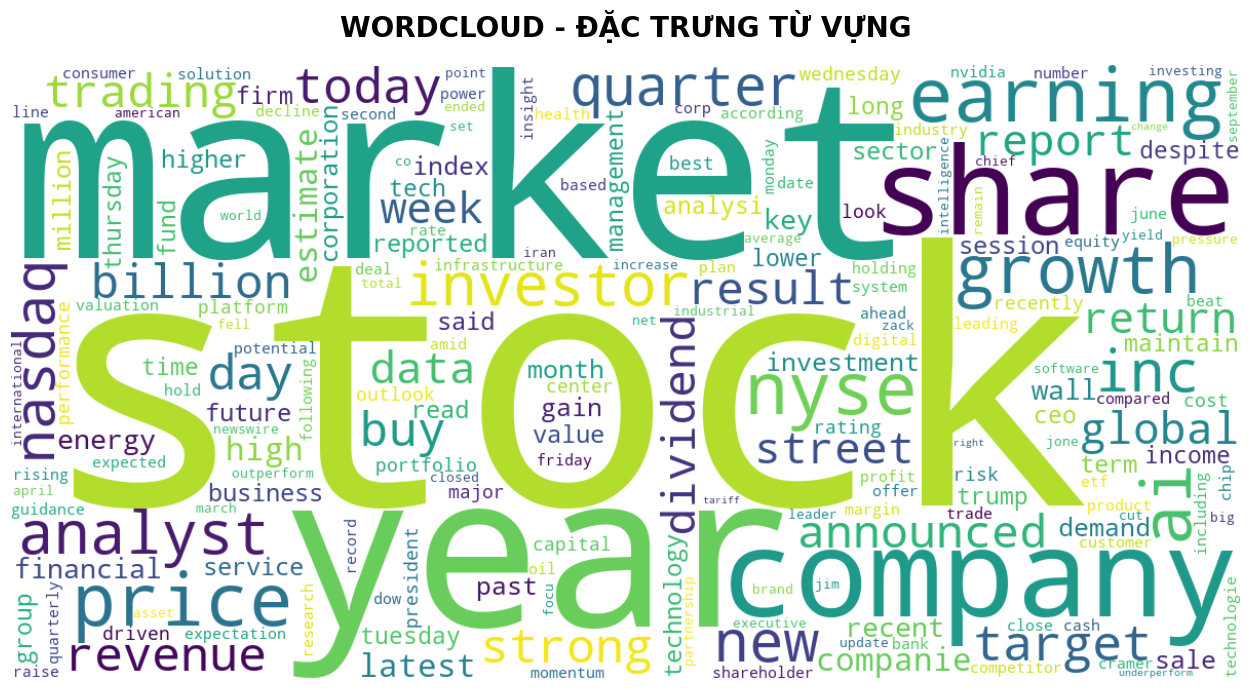

✅ Vẽ WordCloud thành công!


In [7]:
# =========================================================
# 5. CẤU HÌNH VÀ VẼ BIỂU ĐỒ WORDCLOUD
# =========================================================
print("🎨 Đang tạo WordCloud...")

wordcloud = WordCloud(
    width=1200, 
    height=600, 
    background_color='white', 
    colormap='viridis',     # Bảng màu (thử đổi sang 'plasma', 'Blues' nếu thích)
    max_words=200,          # Giới hạn 200 từ xuất hiện nhiều nhất
    collocations=False      # Tắt ghép từ tự động vì đã tokenize
).generate(all_words)

# Hiển thị hình ảnh
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Ẩn trục tọa độ
plt.title("WORDCLOUD - ĐẶC TRƯNG TỪ VỰNG", fontsize=20, fontweight='bold', pad=20)
plt.show()

print("✅ Vẽ WordCloud thành công!")

📥 Đang chuẩn bị dữ liệu văn bản...


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `title_text` cannot be resolved. Did you mean one of the following? [`title_tokens`, `id`, `published_at`, `summary_tokens`].;
'Project [concat_ws( , 'title_text) AS text#44]
+- Filter isnotnull(summary_tokens#31)
   +- SubqueryAlias my_catalog.processed_zone_finnhub.news_tokens
      +- RelationV2[id#28L, published_at#29, title_tokens#30, summary_tokens#31] my_catalog.processed_zone_finnhub.news_tokens my_catalog.processed_zone_finnhub.news_tokens
